In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all 3 datasets
df1 = pd.read_csv("gym_members_exercise_tracking.csv")
df2 = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
df3 = pd.read_csv("health_fitness_dataset.csv")

print("Gym Members:", df1.shape)
print("Obesity Dataset:", df2.shape)
print("Health Fitness:", df3.shape)

# Check columns of each
print("\nGym Members columns:", list(df1.columns))
print("\nObesity columns:", list(df2.columns))
print("\nHealth Fitness columns:", list(df3.columns))

Gym Members: (973, 15)
Obesity Dataset: (2111, 17)
Health Fitness: (687701, 23)

Gym Members columns: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']

Obesity columns: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']

Health Fitness columns: ['participant_id', 'date', 'age', 'gender', 'height_cm', 'weight_kg', 'bmi', 'activity_type', 'duration_minutes', 'intensity', 'calories_burned', 'daily_steps', 'avg_heart_rate', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'endurance_level', 'sleep_hours', 'stress_level', 'hydration_level', 'smoking_status', 'health_condition', 'fitness_level']


In [3]:
# Step 1 — Standardize Gym Members dataset
gym_std = pd.DataFrame()
gym_std['age'] = df1['Age']
gym_std['gender'] = df1['Gender']
gym_std['height_m'] = df1['Height (m)']
gym_std['weight_kg'] = df1['Weight (kg)']
gym_std['bmi'] = df1['BMI']
gym_std['calories_burned'] = df1['Calories_Burned']
gym_std['avg_heart_rate'] = df1['Avg_BPM']
gym_std['resting_heart_rate'] = df1['Resting_BPM']
gym_std['water_intake_liters'] = df1['Water_Intake (liters)']
gym_std['fat_percentage'] = df1['Fat_Percentage']
gym_std['workout_frequency'] = df1['Workout_Frequency (days/week)']
gym_std['experience_level'] = df1['Experience_Level']
gym_std['workout_type'] = df1['Workout_Type']
gym_std['session_duration_hours'] = df1['Session_Duration (hours)']
gym_std['source'] = 'gym_members'

print("Gym standardized:", gym_std.shape)
print(gym_std.head(2))

Gym standardized: (973, 15)
   age  gender  height_m  weight_kg   bmi  calories_burned  avg_heart_rate  \
0   56    Male      1.71       88.3  30.2           1313.0             157   
1   46  Female      1.53       74.9  32.0            883.0             151   

   resting_heart_rate  water_intake_liters  fat_percentage  workout_frequency  \
0                  60                  3.5            12.6                  4   
1                  66                  2.1            33.9                  4   

   experience_level workout_type  session_duration_hours       source  
0                 3         Yoga                    1.69  gym_members  
1                 2         HIIT                    1.30  gym_members  


In [4]:
# Step 2 — Standardize Obesity dataset
obesity_std = pd.DataFrame()
obesity_std['age'] = df2['Age']
obesity_std['gender'] = df2['Gender']
obesity_std['height_m'] = df2['Height']  # already in meters
obesity_std['weight_kg'] = df2['Weight']
obesity_std['bmi'] = obesity_std['weight_kg'] / (obesity_std['height_m'] ** 2)
obesity_std['calories_burned'] = np.nan  # not available
obesity_std['avg_heart_rate'] = np.nan  # not available
obesity_std['resting_heart_rate'] = np.nan  # not available
obesity_std['water_intake_liters'] = df2['CH2O']  # scale 1-3
obesity_std['fat_percentage'] = np.nan  # not available
obesity_std['workout_frequency'] = df2['FAF']  # physical activity frequency
obesity_std['experience_level'] = np.nan  # not available
obesity_std['workout_type'] = np.nan  # not available
obesity_std['session_duration_hours'] = np.nan  # not available
obesity_std['obesity_level'] = df2['NObeyesdad']  # bonus column!
obesity_std['smoking'] = df2['SMOKE']
obesity_std['source'] = 'obesity_lifestyle'

print("Obesity standardized:", obesity_std.shape)
print(obesity_std.head(2))

Obesity standardized: (2111, 17)
   age  gender  height_m  weight_kg        bmi  calories_burned  \
0   21  Female      1.62       64.0  24.386526              NaN   
1   21  Female      1.52       56.0  24.238227              NaN   

   avg_heart_rate  resting_heart_rate  water_intake_liters  fat_percentage  \
0             NaN                 NaN                  2.0             NaN   
1             NaN                 NaN                  3.0             NaN   

   workout_frequency  experience_level  workout_type  session_duration_hours  \
0                0.0               NaN           NaN                     NaN   
1                3.0               NaN           NaN                     NaN   

   obesity_level smoking             source  
0  Normal_Weight      no  obesity_lifestyle  
1  Normal_Weight     yes  obesity_lifestyle  


In [5]:
# Standardize Health Fitness dataset — rename columns, convert height from cm to meters, sample 5000 rows to keep dataset balanced
df3_sample = df3.sample(n=5000, random_state=42)

health_std = pd.DataFrame()
health_std['age'] = df3_sample['age']
health_std['gender'] = df3_sample['gender']
health_std['height_m'] = df3_sample['height_cm'] / 100  # convert cm to meters
health_std['weight_kg'] = df3_sample['weight_kg']
health_std['bmi'] = df3_sample['bmi']
health_std['calories_burned'] = df3_sample['calories_burned']
health_std['avg_heart_rate'] = df3_sample['avg_heart_rate']
health_std['resting_heart_rate'] = df3_sample['resting_heart_rate']
health_std['water_intake_liters'] = df3_sample['hydration_level']
health_std['fat_percentage'] = np.nan  # not available
health_std['workout_frequency'] = np.nan  # not available
health_std['experience_level'] = np.nan  # not available
health_std['workout_type'] = df3_sample['activity_type']
health_std['session_duration_hours'] = df3_sample['duration_minutes'] / 60  # convert to hours
health_std['obesity_level'] = np.nan  # not available
health_std['smoking'] = df3_sample['smoking_status']
health_std['health_condition'] = df3_sample['health_condition']  # bonus — disease info!
health_std['blood_pressure_systolic'] = df3_sample['blood_pressure_systolic']  # bonus!
health_std['stress_level'] = df3_sample['stress_level']  # bonus!
health_std['source'] = 'health_fitness'

print("Health Fitness standardized:", health_std.shape)
print(health_std.head(2))

Health Fitness standardized: (5000, 20)
        age gender  height_m  weight_kg    bmi  calories_burned  \
132800   58      F     1.604      54.49  21.18             15.5   
443248   34      F     1.738      61.88  20.49             22.2   

        avg_heart_rate  resting_heart_rate  water_intake_liters  \
132800             113                63.8                  1.6   
443248             155                61.4                  1.9   

        fat_percentage  workout_frequency  experience_level     workout_type  \
132800             NaN                NaN               NaN         Swimming   
443248             NaN                NaN               NaN  Weight Training   

        session_duration_hours  obesity_level smoking health_condition  \
132800                1.968333            NaN   Never              NaN   
443248                1.850000            NaN   Never         Diabetes   

        blood_pressure_systolic  stress_level          source  
132800                    12

In [6]:
# Merge all 3 standardized datasets vertically — stack them on top of each other into one master dataset
master_df = pd.concat([gym_std, obesity_std, health_std], ignore_index=True)

print("Master Dataset Shape:", master_df.shape)
print("\nRecords per source:")
print(master_df['source'].value_counts())
print("\nMissing values per column:")
print(master_df.isnull().sum())

Master Dataset Shape: (8084, 20)

Records per source:
source
health_fitness       5000
obesity_lifestyle    2111
gym_members           973
Name: count, dtype: int64

Missing values per column:
age                           0
gender                        0
height_m                      0
weight_kg                     0
bmi                           0
calories_burned            2111
avg_heart_rate             2111
resting_heart_rate         2111
water_intake_liters           0
fat_percentage             7111
workout_frequency          5000
experience_level           7111
workout_type               2111
session_duration_hours     2111
source                        0
obesity_level              5973
smoking                     973
health_condition           6632
blood_pressure_systolic    3084
stress_level               3084
dtype: int64


In [7]:
# Fill missing values — numerical columns get median, categorical columns get 'Unknown'
# We use median instead of mean because it's more robust to outliers

# Numerical columns — fill with median
num_cols = ['calories_burned', 'avg_heart_rate', 'resting_heart_rate', 
            'fat_percentage', 'workout_frequency', 'session_duration_hours',
            'blood_pressure_systolic', 'stress_level']

for col in num_cols:
    master_df[col].fillna(master_df[col].median(), inplace=True)

# Categorical columns — fill with 'Unknown'
cat_cols = ['workout_type', 'experience_level', 'obesity_level', 
            'smoking', 'health_condition']

for col in cat_cols:
    master_df[col].fillna('Unknown', inplace=True)

print("Missing values after cleaning:")
print(master_df.isnull().sum())
print("\nMaster dataset shape:", master_df.shape)
print("\nSample:")
print(master_df.head(3))

Missing values after cleaning:
age                        0
gender                     0
height_m                   0
weight_kg                  0
bmi                        0
calories_burned            0
avg_heart_rate             0
resting_heart_rate         0
water_intake_liters        0
fat_percentage             0
workout_frequency          0
experience_level           0
workout_type               0
session_duration_hours     0
source                     0
obesity_level              0
smoking                    0
health_condition           0
blood_pressure_systolic    0
stress_level               0
dtype: int64

Master dataset shape: (8084, 20)

Sample:
   age  gender  height_m  weight_kg    bmi  calories_burned  avg_heart_rate  \
0   56    Male      1.71       88.3  30.20           1313.0           157.0   
1   46  Female      1.53       74.9  32.00            883.0           151.0   
2   32  Female      1.66       68.1  24.71            677.0           122.0   

   resting_heart

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5916\3908339985.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  master_df[col].fillna(master_df[col].median(), inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5916\3908339985.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [8]:
# Fix FutureWarning — use proper pandas syntax for filling missing values
for col in num_cols:
    master_df[col] = master_df[col].fillna(master_df[col].median())

for col in cat_cols:
    master_df[col] = master_df[col].fillna('Unknown')

print("No more warnings! Dataset ready.")
print("Final shape:", master_df.shape)

No more warnings! Dataset ready.
Final shape: (8084, 20)


In [9]:
# Save the merged master dataset to CSV so we don't have to redo this every time
master_df.to_csv("master_health_fitness.csv", index=False)
print("Master dataset saved successfully!")
print("Total records:", len(master_df))
print("Total features:", master_df.shape[1])

Master dataset saved successfully!
Total records: 8084
Total features: 20


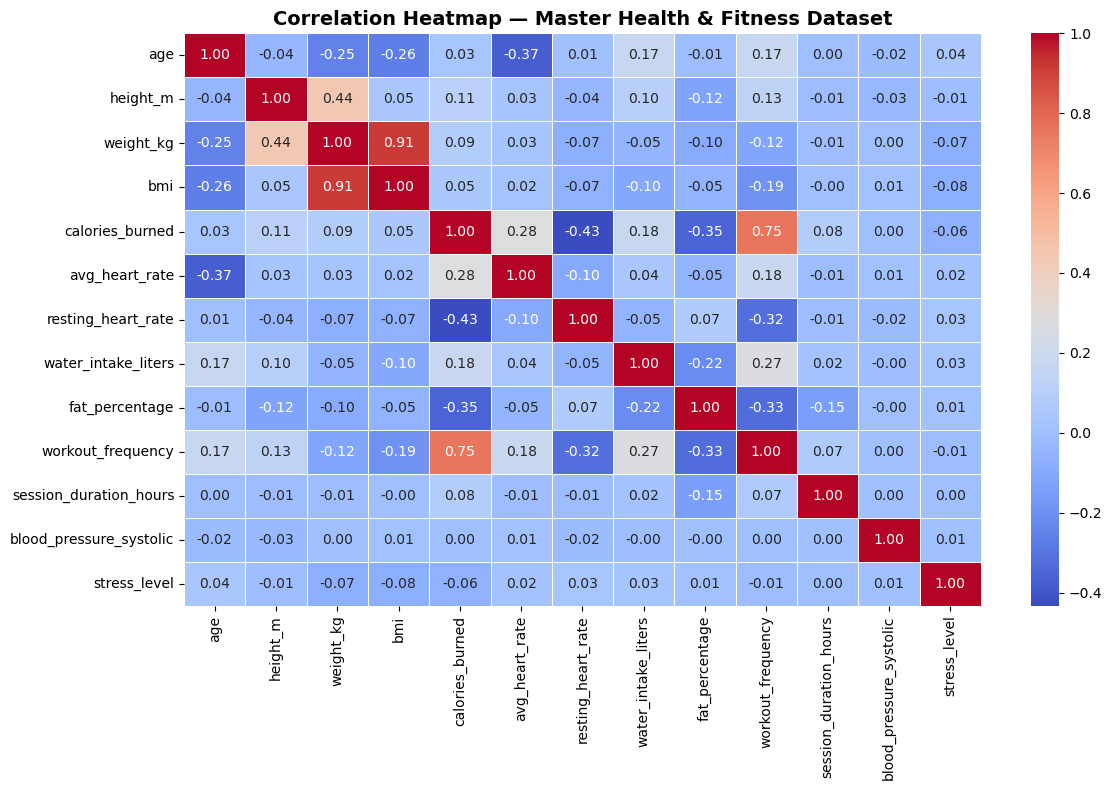


Top correlations with Calories Burned:
calories_burned            1.000000
workout_frequency          0.753891
avg_heart_rate             0.281344
water_intake_liters        0.176158
height_m                   0.114284
weight_kg                  0.085844
session_duration_hours     0.084834
bmi                        0.051739
age                        0.031942
blood_pressure_systolic    0.002664
stress_level              -0.064601
fat_percentage            -0.353805
resting_heart_rate        -0.433490
Name: calories_burned, dtype: float64


In [10]:
# Check correlation between numerical features and calories_burned — our main target variable
numerical_cols = ['age', 'height_m', 'weight_kg', 'bmi', 'calories_burned', 
                  'avg_heart_rate', 'resting_heart_rate', 'water_intake_liters',
                  'fat_percentage', 'workout_frequency', 'session_duration_hours',
                  'blood_pressure_systolic', 'stress_level']

plt.figure(figsize=(12, 8))
correlation = master_df[numerical_cols].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap — Master Health & Fitness Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("master_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with calories_burned
print("\nTop correlations with Calories Burned:")
print(correlation['calories_burned'].sort_values(ascending=False))

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns so ML models can read them
le = LabelEncoder()
master_df['gender_encoded'] = le.fit_transform(master_df['gender'])
master_df['workout_type_encoded'] = le.fit_transform(master_df['workout_type'])

# Select features and target variable
features = ['age', 'height_m', 'weight_kg', 'bmi', 'avg_heart_rate', 
            'resting_heart_rate', 'water_intake_liters', 'fat_percentage',
            'workout_frequency', 'session_duration_hours', 
            'blood_pressure_systolic', 'stress_level',
            'gender_encoded', 'workout_type_encoded']

X = master_df[features]
y = master_df['calories_burned']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Features:", len(features))

Training samples: 6467
Testing samples: 1617
Features: 14


In [12]:
# Train 3 ML models and compare their performance on predicting calories burned

# Model 1 — Linear Regression (simple baseline model)
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Model 2 — Random Forest (ensemble of decision trees)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Model 3 — Gradient Boosting (builds trees sequentially, each correcting previous errors)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

# Evaluate all 3 models using R², MAE and RMSE
def evaluate(name, y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"\n{name}")
    print(f"  R² Score : {r2:.4f}")
    print(f"  MAE      : {mae:.2f} calories")
    print(f"  RMSE     : {rmse:.2f} calories")

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)
evaluate("Gradient Boosting", y_test, gb_pred)


Linear Regression
  R² Score : 0.6779
  MAE      : 120.05 calories
  RMSE     : 168.45 calories

Random Forest
  R² Score : 0.9928
  MAE      : 9.59 calories
  RMSE     : 25.13 calories

Gradient Boosting
  R² Score : 0.9892
  MAE      : 12.27 calories
  RMSE     : 30.90 calories


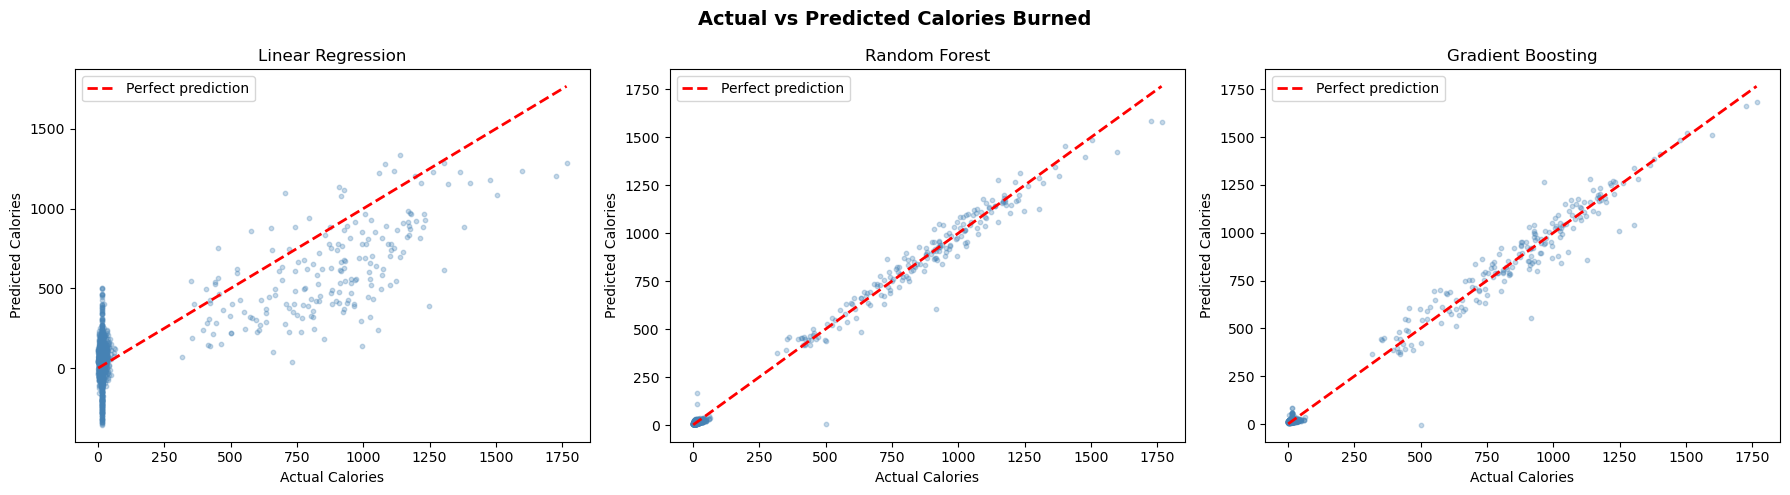

In [13]:
# Plot actual vs predicted calories for all 3 models to visualize performance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Actual vs Predicted Calories Burned", fontsize=14, fontweight='bold')

models = [("Linear Regression", lr_pred), 
          ("Random Forest", rf_pred), 
          ("Gradient Boosting", gb_pred)]

for ax, (name, pred) in zip(axes, models):
    ax.scatter(y_test, pred, alpha=0.3, color='steelblue', s=10)
    ax.plot([y_test.min(), y_test.max()], 
            [y_test.min(), y_test.max()], 
            'r--', linewidth=2, label='Perfect prediction')
    ax.set_xlabel("Actual Calories")
    ax.set_ylabel("Predicted Calories")
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5916\344503334.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature', palette='coolwarm')


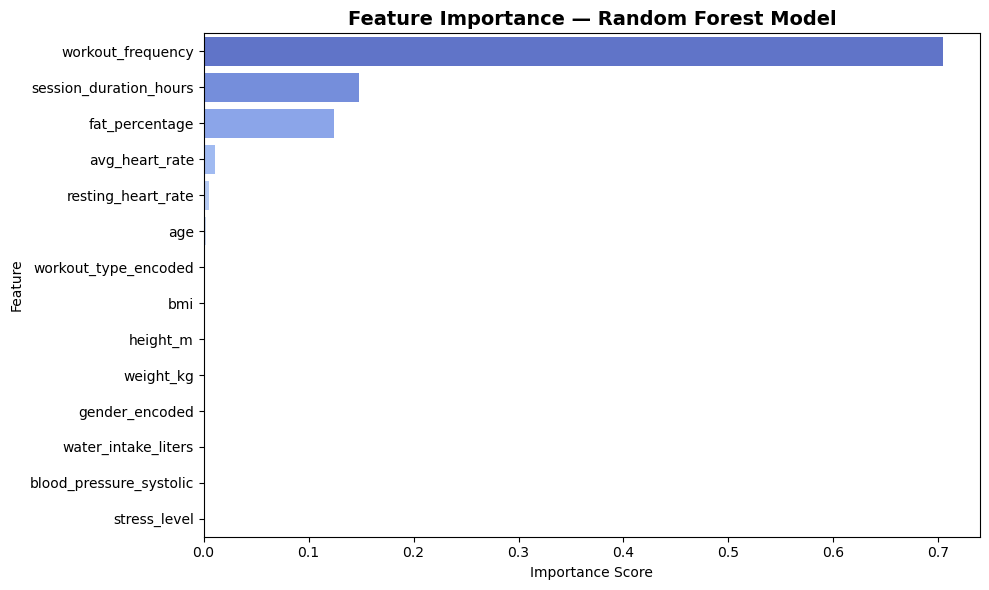


Feature Importance Rankings:
                feature  importance
      workout_frequency    0.704460
 session_duration_hours    0.148062
         fat_percentage    0.123849
         avg_heart_rate    0.011239
     resting_heart_rate    0.005223
                    age    0.002116
   workout_type_encoded    0.001542
                    bmi    0.000889
               height_m    0.000734
              weight_kg    0.000716
         gender_encoded    0.000664
    water_intake_liters    0.000420
blood_pressure_systolic    0.000064
           stress_level    0.000023


In [14]:
# Feature importance — shows which variables contribute most to Random Forest predictions
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='coolwarm')
plt.title("Feature Importance — Random Forest Model", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Importance Rankings:")
print(feature_importance.to_string(index=False))

In [15]:
# Check what health conditions exist in our dataset
print("Health Conditions in Dataset:")
print(master_df['health_condition'].value_counts())

print("\nObesity Levels:")
print(master_df['obesity_level'].value_counts())

Health Conditions in Dataset:
health_condition
Unknown         6632
Hypertension     739
Diabetes         479
Asthma           234
Name: count, dtype: int64

Obesity Levels:
obesity_level
Unknown                5973
Obesity_Type_I          351
Obesity_Type_III        324
Obesity_Type_II         297
Overweight_Level_I      290
Overweight_Level_II     290
Normal_Weight           287
Insufficient_Weight     272
Name: count, dtype: int64


In [16]:
# Build a classification model to predict disease risk (Healthy vs At Risk)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Create binary target — Healthy (0) vs At Risk (1)
# At Risk = has Diabetes, Hypertension, or Obesity
master_df['disease_risk'] = 0  # default healthy

master_df.loc[master_df['health_condition'].isin(['Diabetes', 'Hypertension', 'Asthma']), 'disease_risk'] = 1
master_df.loc[master_df['obesity_level'].isin([
    'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III',
    'Overweight_Level_I', 'Overweight_Level_II'
]), 'disease_risk'] = 1

print("Disease Risk Distribution:")
print(master_df['disease_risk'].value_counts())
print("\n0 = Healthy, 1 = At Risk")

Disease Risk Distribution:
disease_risk
0    5080
1    3004
Name: count, dtype: int64

0 = Healthy, 1 = At Risk


In [17]:
# Train Random Forest classifier to predict whether a person is at risk of lifestyle disease
# based on their physiological and behavioral data

X_disease = master_df[features]
y_disease = master_df['disease_risk']

# Split into 80% training and 20% testing
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_disease, y_disease, test_size=0.2, random_state=42)

# Train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_d, y_train_d)
y_pred_d = rf_classifier.predict(X_test_d)

# Evaluate the model
from sklearn.metrics import accuracy_score
print("Disease Risk Prediction Results:")
print(f"Accuracy: {accuracy_score(y_test_d, y_pred_d):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test_d, y_pred_d, 
      target_names=['Healthy', 'At Risk']))

Disease Risk Prediction Results:
Accuracy: 0.8330

Detailed Report:
              precision    recall  f1-score   support

     Healthy       0.79      0.99      0.88      1026
     At Risk       0.98      0.55      0.71       591

    accuracy                           0.83      1617
   macro avg       0.89      0.77      0.80      1617
weighted avg       0.86      0.83      0.82      1617



C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5916\469175024.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=disease_importance, x='importance',


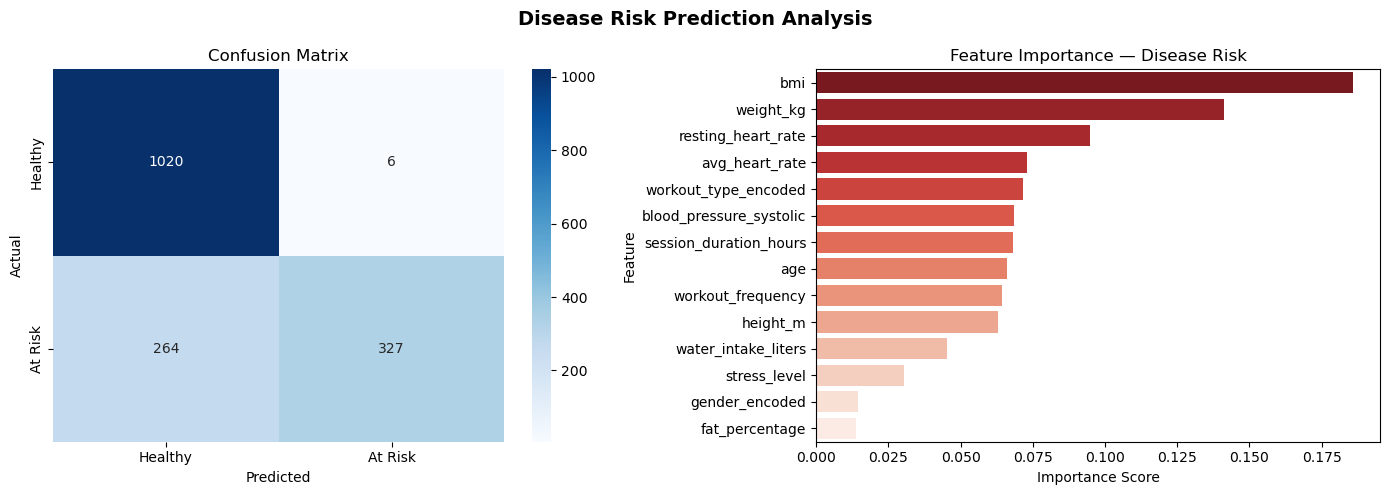


Disease Risk Feature Importance:
                feature  importance
                    bmi    0.185894
              weight_kg    0.141217
     resting_heart_rate    0.094708
         avg_heart_rate    0.072978
   workout_type_encoded    0.071708
blood_pressure_systolic    0.068543
 session_duration_hours    0.067985
                    age    0.066005
      workout_frequency    0.064309
               height_m    0.062912
    water_intake_liters    0.045313
           stress_level    0.030241
         gender_encoded    0.014545
         fat_percentage    0.013644


In [18]:
# Visualize confusion matrix and feature importance for disease risk model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Disease Risk Prediction Analysis", fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test_d, y_pred_d)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Healthy', 'At Risk'],
            yticklabels=['Healthy', 'At Risk'])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Feature Importance for Disease Risk
disease_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

sns.barplot(data=disease_importance, x='importance', 
            y='feature', palette='Reds_r', ax=axes[1])
axes[1].set_title("Feature Importance — Disease Risk")
axes[1].set_xlabel("Importance Score")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.savefig("disease_risk_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nDisease Risk Feature Importance:")
print(disease_importance.to_string(index=False))
